In [1]:
import duckdb
import matplotlib.pyplot as plt

# A single in-memory connection is reused for all views throughout this notebook
con = duckdb.connect()

In [2]:
# DuckDB reads CSV files directly — timestamps and types are auto-inferred
con.sql("SELECT * FROM 'data/MrBeast_youtube_stats.csv' LIMIT 3").show()

┌─────────────┬──────────────────────────────────┬─────────────┬───────────────────────────┬───────────────┬──────────────────┬─────────────┬────────────┬──────────────┬────────────────────────────────────────────────┬──────────────────────────┬───────────────────────────┬──────────────────────────────────────────────────┬─────────────────────────┬──────────────────────────┬──────────────────────────────────────────────────┬───────────────────────┬────────────────────────┬─────────────────────────┬──────────────────────────┬──────────────────────────────────────────────────────────────────────────────────────┬─────────────────────────┬──────────────────────────────────┬──────────────────────────────┬──────────────┬──────────────────────────────────┐
│     id      │              title               │ description │        publishTime        │  kind_stats   │ duration_seconds │  viewCount  │ likeCount  │ commentCount │             thumbnails.default.url             │ thumbnails.default.wi

In [3]:
con.sql("""
    SELECT id, COUNT(DISTINCT title) AS title_count
    FROM 'data/MrBeast_youtube_stats.csv'
    GROUP BY id
    ORDER BY title_count DESC
""").show()

┌─────────────┬─────────────┐
│     id      │ title_count │
│   varchar   │    int64    │
├─────────────┼─────────────┤
│ NULL        │          12 │
│ 0CTp1a-aCUM │           5 │
│ 65fN_OUawjk │           4 │
│ vBpQ1SlfVtU │           4 │
│ 2isYuQZMbdU │           4 │
│ 9RhWXPcKBI8 │           3 │
│ hTSaweR8qMI │           3 │
│ mKdjycj-7eE │           3 │
│ tVWWp1PqDus │           3 │
│ zajUgQLviwk │           3 │
│      ·      │           · │
│      ·      │           · │
│      ·      │           · │
│ CWK6an4mYL0 │           1 │
│ aZnqqXaT02g │           1 │
│ VqnQ-0q2gb4 │           1 │
│ NFZ_MtTvwm0 │           1 │
│ UVin8WtE5eU │           1 │
│ X_qd-1xSTFA │           1 │
│ bwp_3qLgWpQ │           1 │
│ boBokLXe5o8 │           1 │
│ XVMY7B3AzWM │           1 │
│ wIpWCJKfRXs │           1 │
└─────────────┴─────────────┘
  943 rows        2 columns
  (20 shown)                



In [4]:
# Cast numerics, rename camelCase -> snake_case, and drop nulls in one view.
# DuckDB is case-insensitive so no quoting needed for camelCase column names.
con.sql("""
    CREATE OR REPLACE VIEW youtube_clean AS
    SELECT
        id,
        title,
        pull_date,
        viewCount::BIGINT    AS view_count,
        likeCount::BIGINT    AS like_count,
        commentCount::BIGINT AS comment_count,
        duration_seconds::DOUBLE AS duration_seconds
    FROM 'data/MrBeast_youtube_stats.csv'
    WHERE viewCount    IS NOT NULL
      AND likeCount    IS NOT NULL
      AND commentCount IS NOT NULL
""")
con.sql("SELECT * FROM youtube_clean LIMIT 3").show()

┌─────────────┬──────────────────────────────────┬──────────────────────────────────┬────────────┬────────────┬───────────────┬──────────────────┐
│     id      │              title               │            pull_date             │ view_count │ like_count │ comment_count │ duration_seconds │
│   varchar   │             varchar              │     timestamp with time zone     │   int64    │   int64    │     int64     │      double      │
├─────────────┼──────────────────────────────────┼──────────────────────────────────┼────────────┼────────────┼───────────────┼──────────────────┤
│ nAiKLoCP-kU │ Reach the Money, Win $10,000     │ 2026-04-12 05:33:53.090879+05:30 │  519905021 │    7925647 │         10527 │             25.0 │
│ 8krJy31Diow │ Holding Bigger And Bigger Dogs   │ 2026-04-12 05:33:53.090879+05:30 │  345577798 │    8208901 │         11014 │             17.0 │
│ 8bTQMDM4qvY │ Spot The Fake Animal For $10,000 │ 2026-04-12 05:33:53.090879+05:30 │  645200251 │   17319159 │       

<Axes: title={'center': 'Number of Videos pulled per day'}, xlabel='pull_date'>

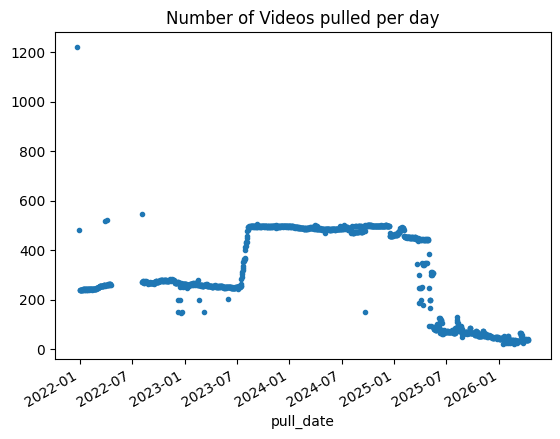

In [5]:
(con.sql("""
    SELECT pull_date::DATE AS pull_date, COUNT(*) AS cnt
    FROM youtube_clean
    GROUP BY pull_date::DATE
    ORDER BY pull_date
""")
.df()
.set_index('pull_date')['cnt']
.plot(style='.', title='Number of Videos pulled per day'))

In [6]:
con.sql("""
    SELECT id, title, MAX(view_count) AS view_count, MAX(pull_date) AS pull_date
    FROM youtube_clean
    GROUP BY id, title
    ORDER BY view_count ASC
""").show()

┌─────────────┬───────────────────────────────────────────────────┬────────────┬──────────────────────────────────┐
│     id      │                       title                       │ view_count │            pull_date             │
│   varchar   │                      varchar                      │   int64    │     timestamp with time zone     │
├─────────────┼───────────────────────────────────────────────────┼────────────┼──────────────────────────────────┤
│ F3fmzCmIJ14 │ This Stream Ends When Someone Wins $1,000,000     │          0 │ 2026-04-05 05:36:18.400542+05:30 │
│ TGKkMl17Htg │ Battle Pirates, Unstoppable Ship!                 │      35956 │ 2023-08-07 05:39:55.117235+05:30 │
│ ywZy_Fo2ydo │ Modern Art Is A Joke                              │      36613 │ 2023-08-27 05:42:06.324381+05:30 │
│ u6t4jrhs56Q │ Top Youtube &quot;ShoutOuts&quot;                 │      36633 │ 2023-08-27 05:42:06.324381+05:30 │
│ 6T17licWsQ4 │ Leaving For 7 Days                                │     

<Axes: xlabel='pull_date'>

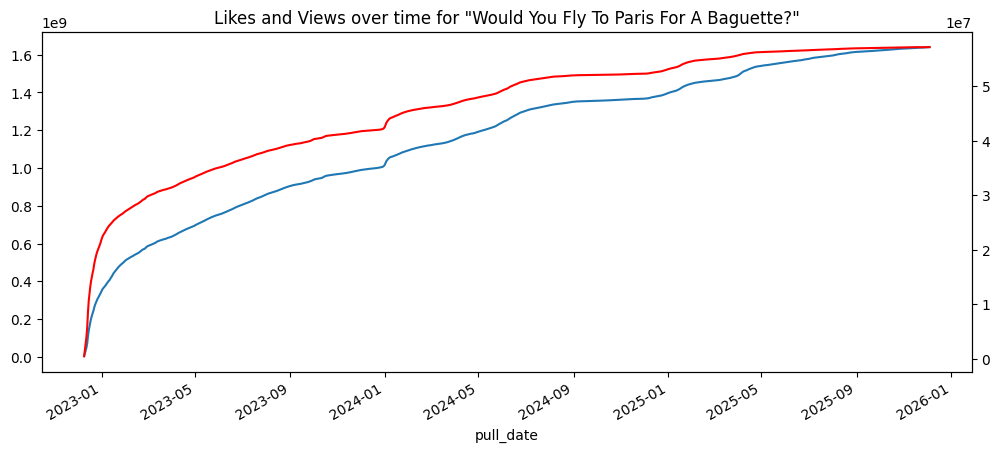

In [7]:
video_name = con.sql("""
    SELECT title FROM youtube_clean WHERE id = 'se50viFJ0AQ' LIMIT 1
""").df()['title'][0]

video_df = con.sql("""
    SELECT pull_date, view_count, like_count
    FROM youtube_clean
    WHERE id = 'se50viFJ0AQ'
    ORDER BY pull_date
""").df().set_index('pull_date')

fig, ax = plt.subplots(figsize=(12, 5))
ax2 = ax.twinx()
video_df['view_count'].plot(ax=ax, title=f'Likes and Views over time for "{video_name}"')
video_df['like_count'].plot(ax=ax2, color='red')

In [8]:
# DuckDB reads Parquet natively; rename camelCase columns for cleaner downstream SQL
con.sql("""
    CREATE OR REPLACE VIEW youtube_base AS
    SELECT
        id, title, pull_date,
        viewCount    AS view_count,
        likeCount    AS like_count,
        commentCount AS comment_count,
        duration_seconds,
        time_since_last_pull,
        view_diff,
        like_diff,
        comment_diff
    FROM 'data/MrBeast_youtube_stats_processed.parquet'
""")
con.sql("SELECT * FROM youtube_base LIMIT 3").show()

┌─────────────┬─────────────────────────────────────────────────┬──────────────────────────────────┬────────────┬────────────┬───────────────┬──────────────────┬──────────────────────┬───────────┬───────────┬──────────────┐
│     id      │                      title                      │            pull_date             │ view_count │ like_count │ comment_count │ duration_seconds │ time_since_last_pull │ view_diff │ like_diff │ comment_diff │
│   varchar   │                     varchar                     │     timestamp with time zone     │   int64    │   int64    │     int64     │      int64       │        int64         │  double   │  double   │    double    │
├─────────────┼─────────────────────────────────────────────────┼──────────────────────────────────┼────────────┼────────────┼───────────────┼──────────────────┼──────────────────────┼───────────┼───────────┼──────────────┤
│ -0zoWMSEOGg │ I Gave My 6,000,000th Subscriber 6,000,000 ____ │ 2021-12-24 07:11:03.667334+05:30 │   1

In [9]:
con.sql("""
    CREATE OR REPLACE VIEW youtube_ratios AS
    SELECT *,
        like_diff / NULLIF(view_diff, 0) AS like_to_view_ratio
    FROM youtube_base
""")

In [10]:
con.sql("""
    SELECT id, title, pull_date, view_diff, like_diff, like_to_view_ratio
    FROM youtube_ratios
    WHERE view_diff != 0
    ORDER BY like_to_view_ratio DESC
""").show()

┌─────────────┬───────────────────────────────────────────────────────────────┬──────────────────────────────────┬───────────┬───────────┬─────────────────────┐
│     id      │                             title                             │            pull_date             │ view_diff │ like_diff │ like_to_view_ratio  │
│   varchar   │                            varchar                            │     timestamp with time zone     │  double   │  double   │       double        │
├─────────────┼───────────────────────────────────────────────────────────────┼──────────────────────────────────┼───────────┼───────────┼─────────────────────┤
│ uotb9ZHnI2g │ Tipping Pizza Delivery Guys $10,000                           │ 2024-05-08 05:40:49.880176+05:30 │     309.0 │  695773.0 │  2251.6925566343043 │
│ 93s1JECSy60 │ Giving My Mom $100,000 (Proudest Day Of My Life)              │ 2024-05-08 05:40:49.880176+05:30 │    1021.0 │ 1529468.0 │  1498.0097943192948 │
│ _uwNDiU04zE │ I Donated $300,000

<Axes: xlabel='pull_date'>

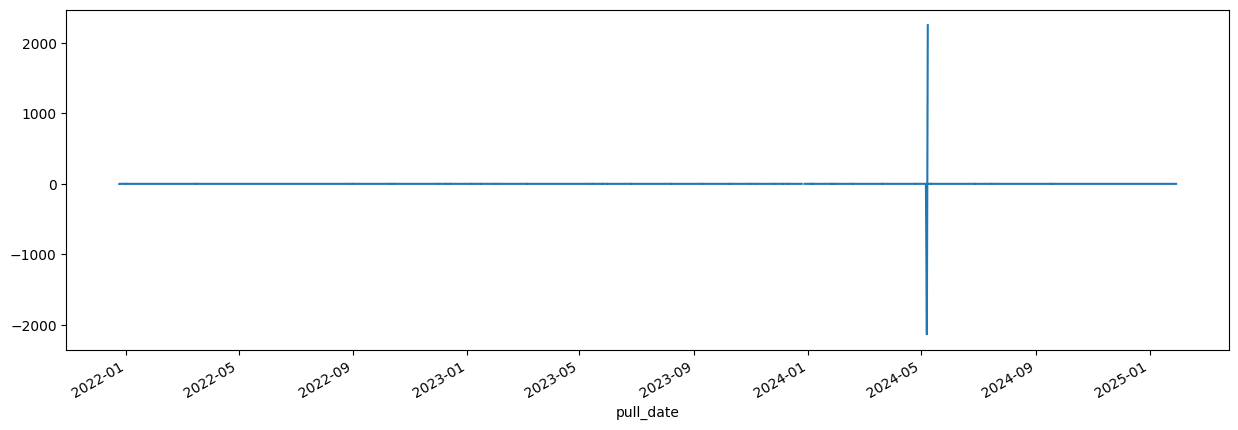

In [11]:
con.sql("""
    SELECT pull_date, like_to_view_ratio
    FROM youtube_ratios
    WHERE id = 'uotb9ZHnI2g'
    ORDER BY pull_date
""").df().set_index('pull_date')['like_to_view_ratio'].plot(figsize=(15, 5))

In [12]:
# time_since_last_pull is stored as BIGINT (Arrow Duration[us] = microseconds).
# Divide by 1e6 to get seconds, then normalise to 12-hour periods.
con.sql("""
    CREATE OR REPLACE VIEW youtube_normalized AS
    SELECT *,
        view_diff / (time_since_last_pull / 1e6 / (60.0 * 60.0 * 12.0)) AS view_diff_norm,
        like_diff / (time_since_last_pull / 1e6 / (60.0 * 60.0 * 12.0)) AS like_diff_norm
    FROM youtube_ratios
""")

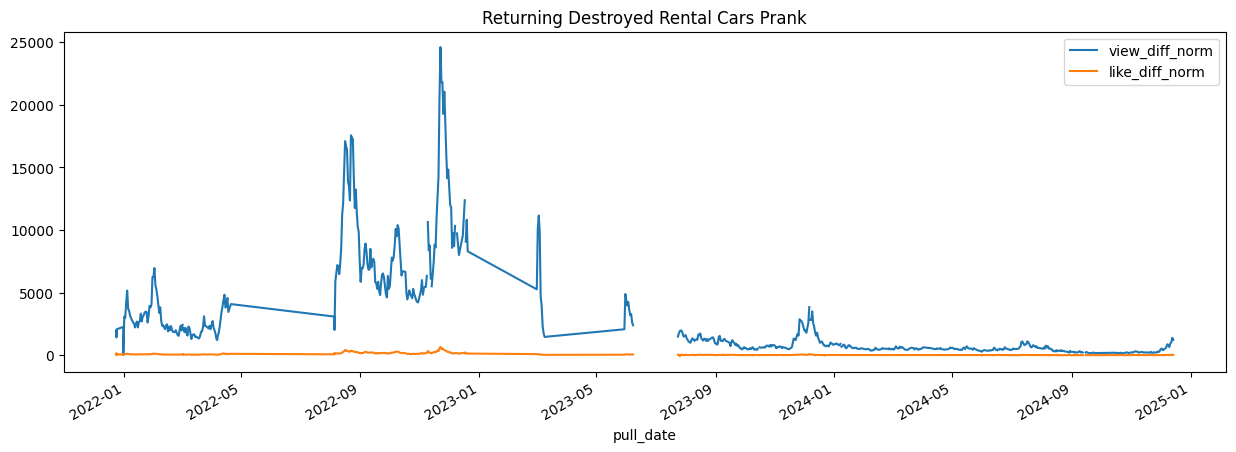

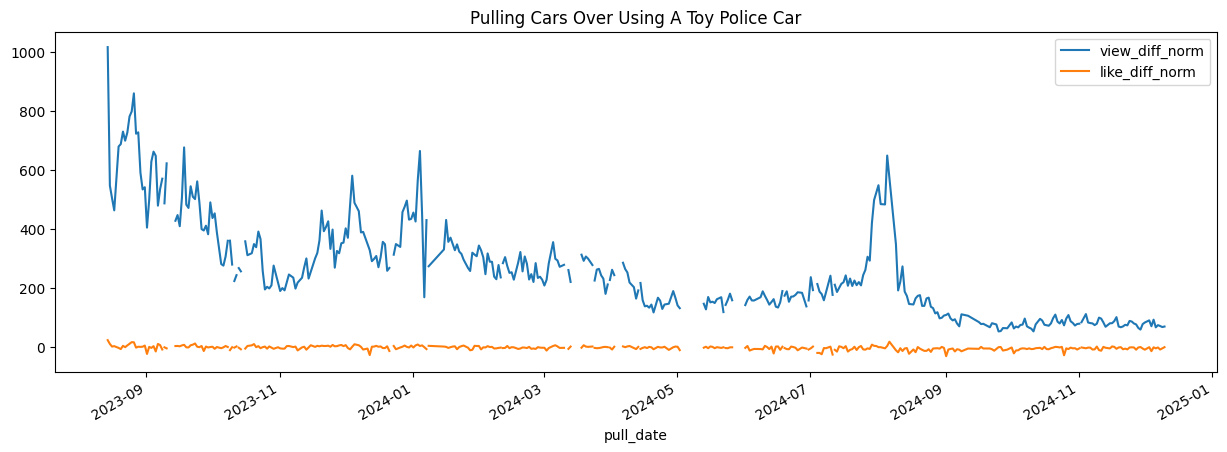

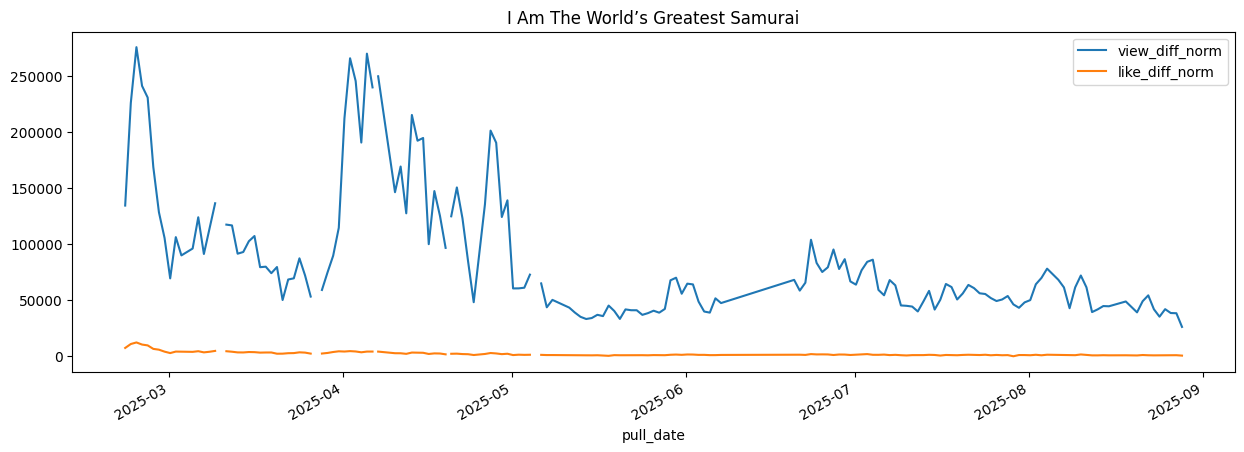

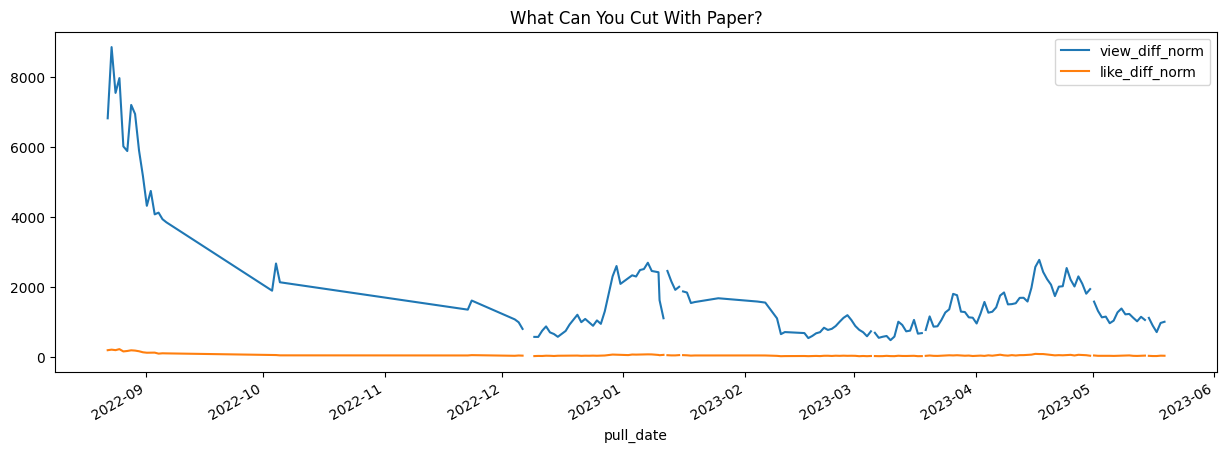

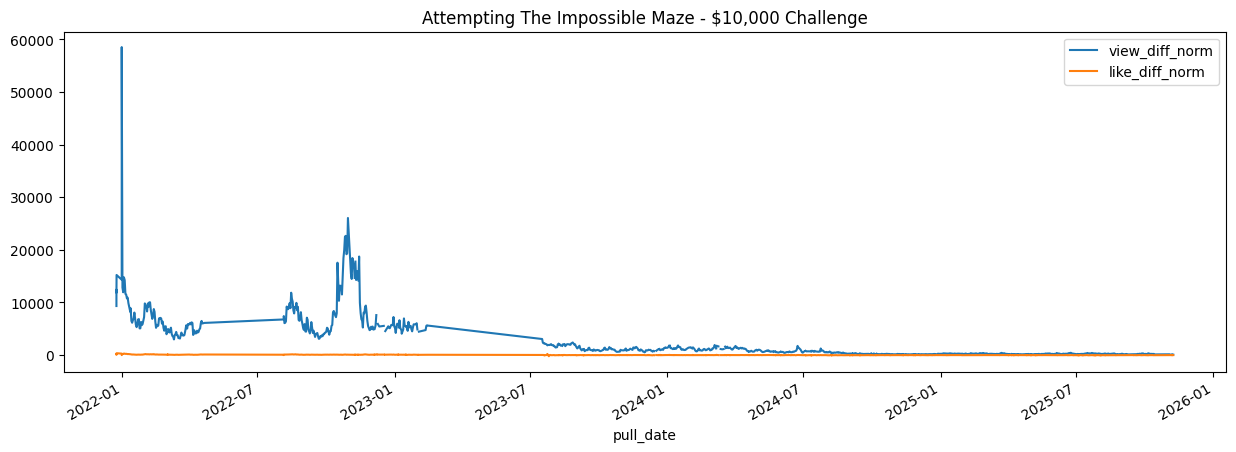

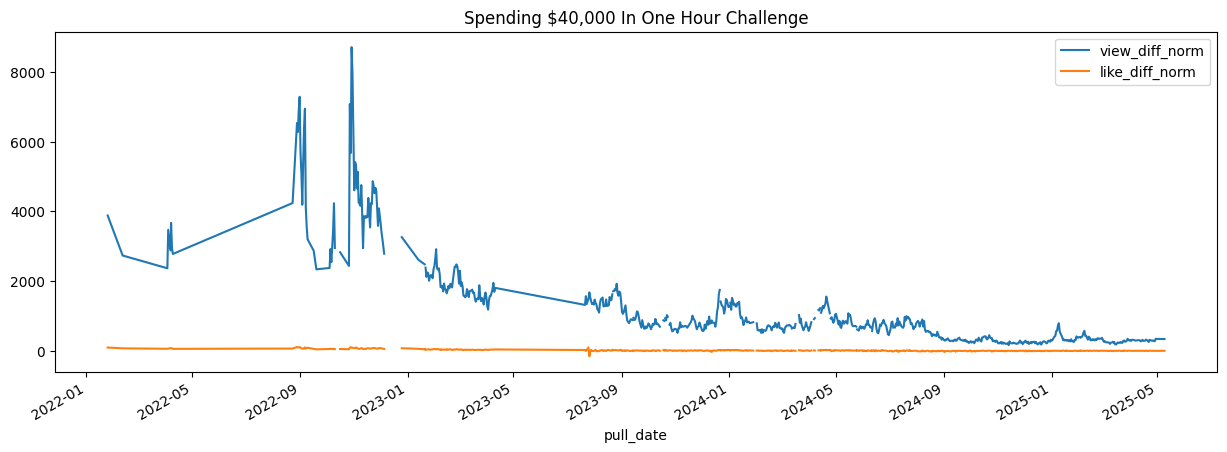

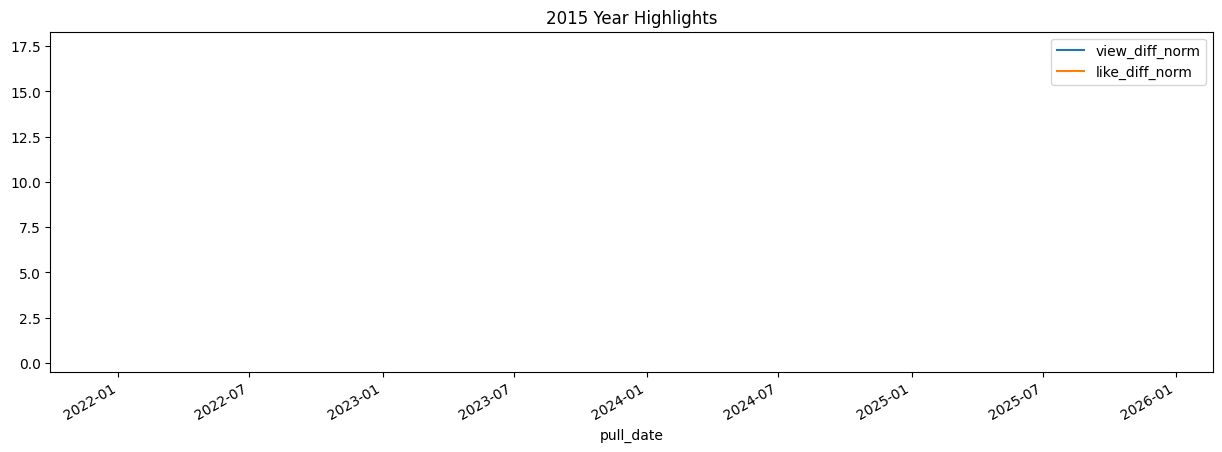

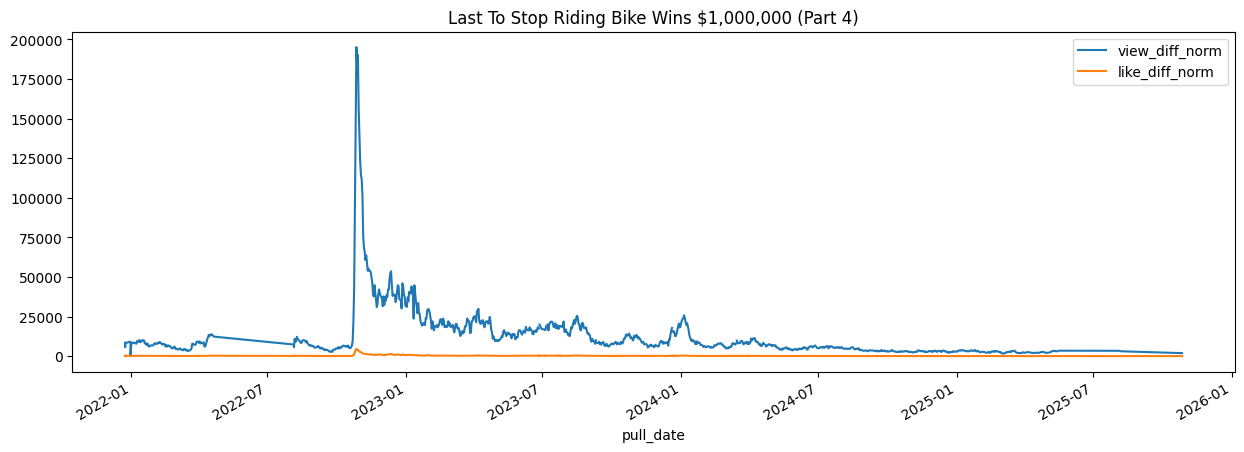

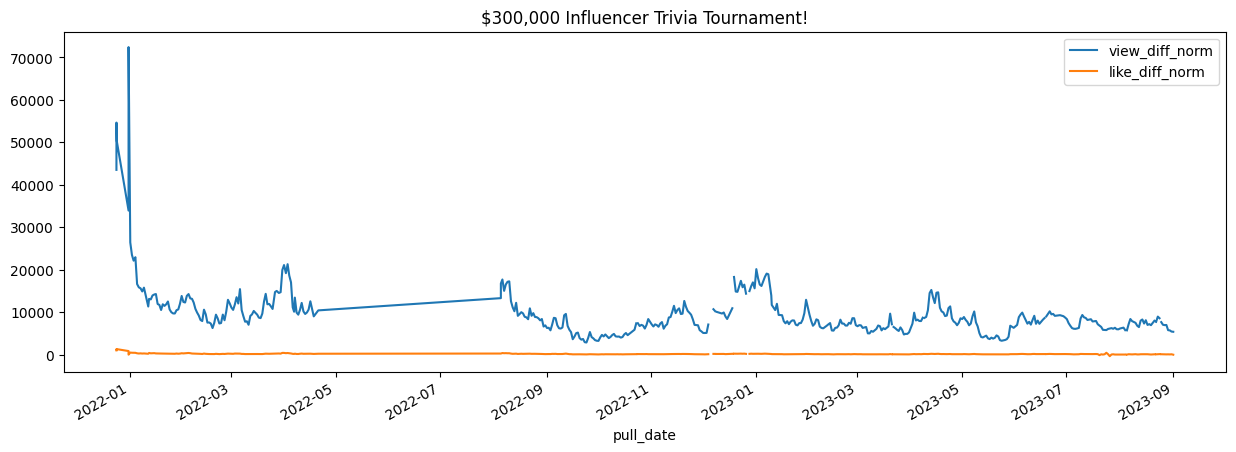

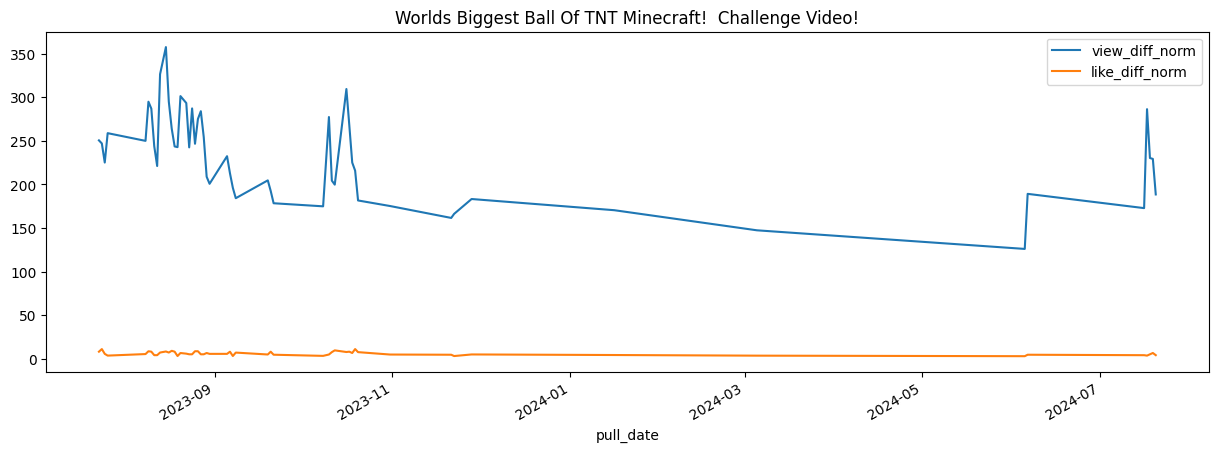

In [13]:
import random

all_ids = con.sql("SELECT DISTINCT id FROM youtube_normalized").df()['id'].tolist()
random.seed(529)
random_vids = random.sample(all_ids, 10)

for v in random_vids:
    vid_title = con.sql(
        f"SELECT title FROM youtube_normalized WHERE id = '{v}' LIMIT 1"
    ).df()['title'][0]
    (con.sql(f"""
        SELECT pull_date, view_diff_norm, like_diff_norm
        FROM youtube_normalized
        WHERE id = '{v}'
        ORDER BY pull_date
    """)
    .df()
    .set_index('pull_date')[['view_diff_norm', 'like_diff_norm']]
    .plot(figsize=(15, 5), title=vid_title))

## Look at videos with crazy ratios

In [14]:
con.sql("""
    CREATE OR REPLACE VIEW youtube_final AS
    SELECT *,
        like_diff_norm / NULLIF(view_diff_norm, 0.0) AS like_ratio_norm
    FROM youtube_normalized
""")

In [15]:
top_10 = con.sql("""
    SELECT title, MAX(like_ratio_norm) AS like_ratio_norm
    FROM youtube_final
    WHERE like_ratio_norm <= 1
      AND view_diff_norm  != 0
    GROUP BY title
    ORDER BY like_ratio_norm DESC
""")
top_10.show()

┌──────────────────────────────────────────────────────────────────────────┬─────────────────────────┐
│                                  title                                   │     like_ratio_norm     │
│                                 varchar                                  │         double          │
├──────────────────────────────────────────────────────────────────────────┼─────────────────────────┤
│ I Gave $500,000 To Random People                                         │                     1.0 │
│ 5$ To Advertise Your Youtube Channel???                                  │                     1.0 │
│ Free To Use Advanced Warfare Gameplay! 2015                              │                     1.0 │
│ Knives In Video Games Cost More Than Real Life????                       │                     1.0 │
│ Epic Ghost Multiplayer EasterEggs! (PrisonBreak, Sovereign, and Flooded) │                     1.0 │
│ I Donated $300,000 To People In Need                                   

In [16]:
# .df() is DuckDB's method to convert a relation to a pandas DataFrame
top_10.df()

,title,like_ratio_norm
0,"I Gave $500,000 To Random People",1.000000
1,5$ To Advertise Your Youtube Channel???,1.000000
2,How To Become A Gaming Youtuber! All You Need ...,1.000000
3,More birds IN MINECRAFT!!,1.000000
4,How Many People Get The Diamond Play Button?????,1.000000
...,...,...
981,"World&#39;s Biggest YouTubers Fight for $1,000...",-0.000384
982,"Get Every Boy Scout Badge, Win $10,000",-0.006398
983,Making Fun Of Youtuber&#39;s Intros.,-0.013158
984,Every Challenge I&#39;ve Ever Done,-0.017544


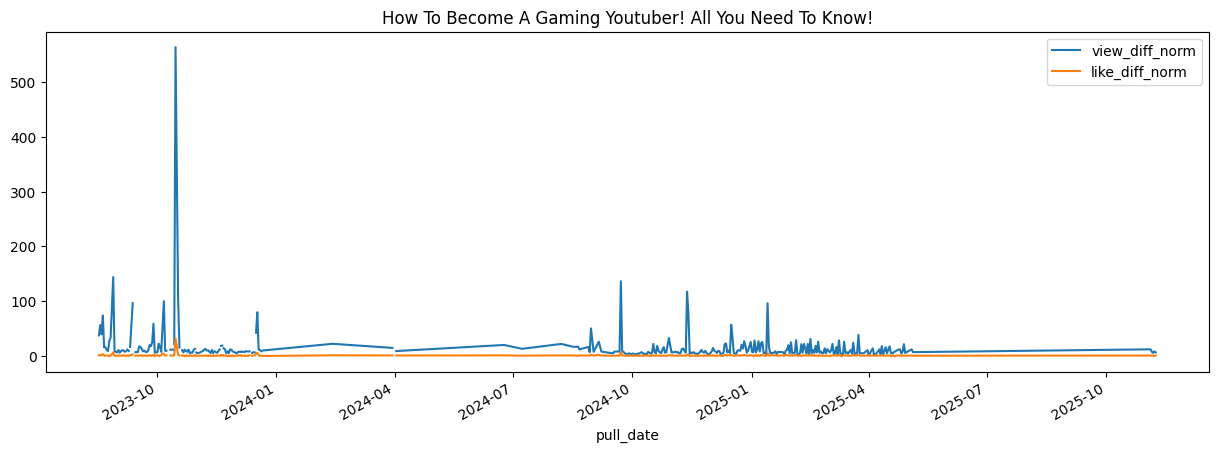

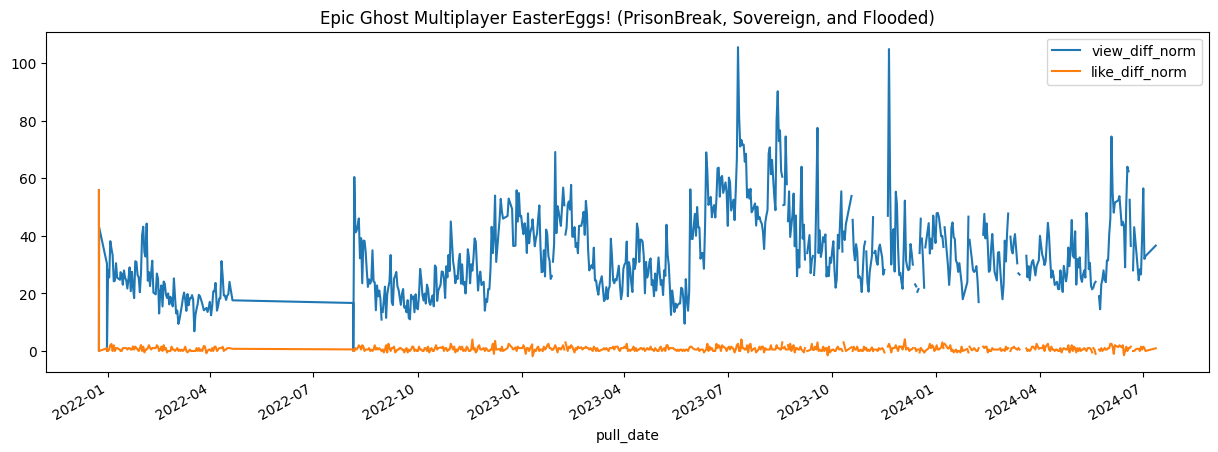

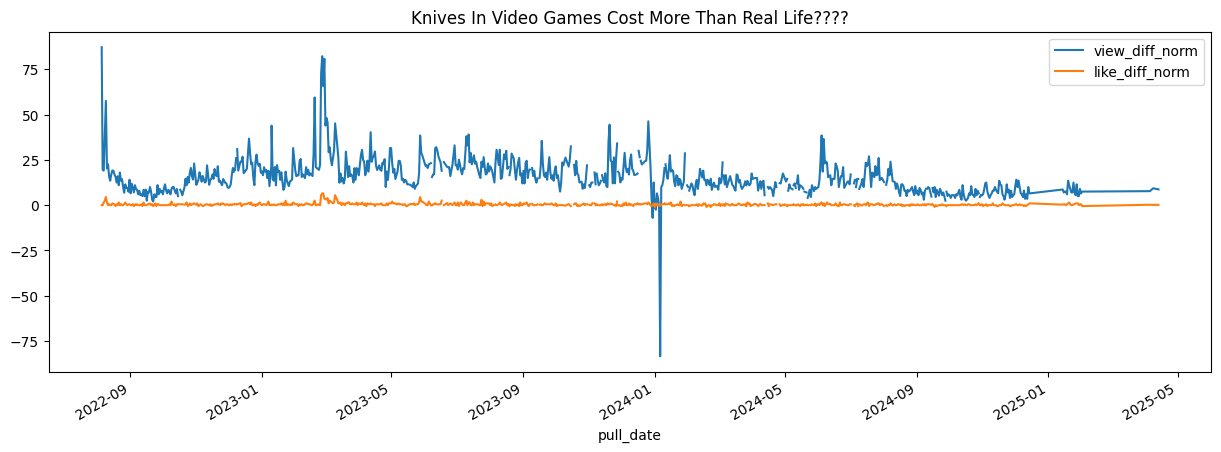

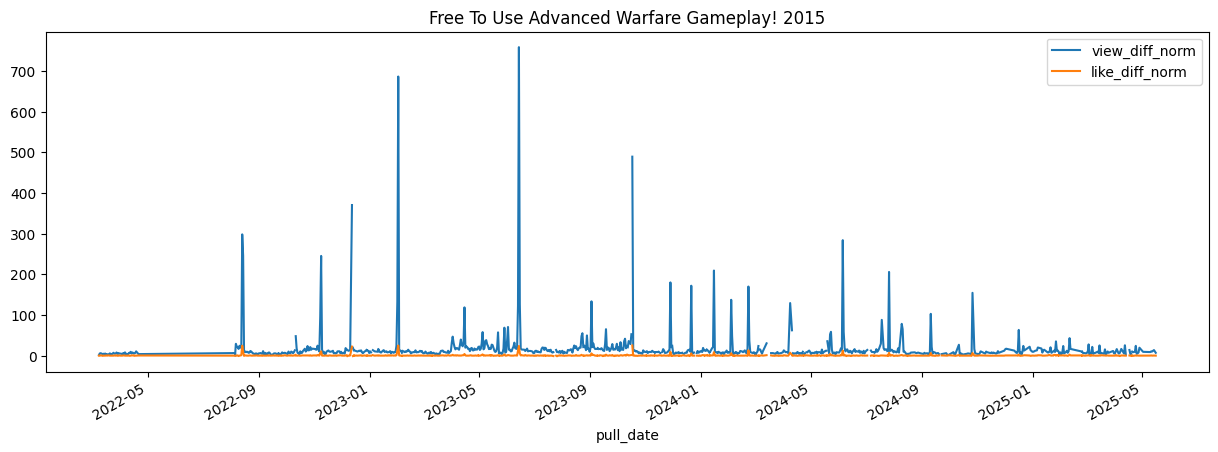

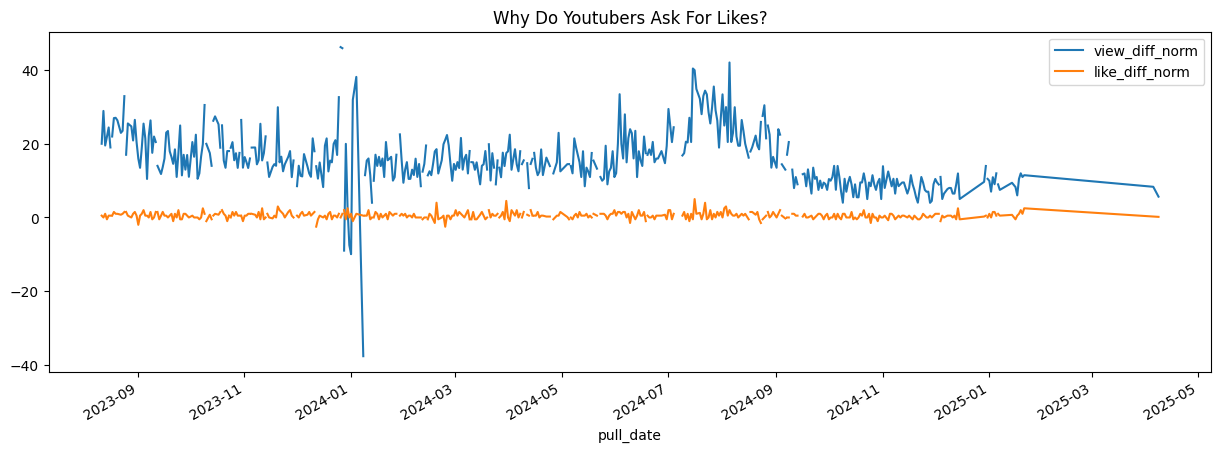

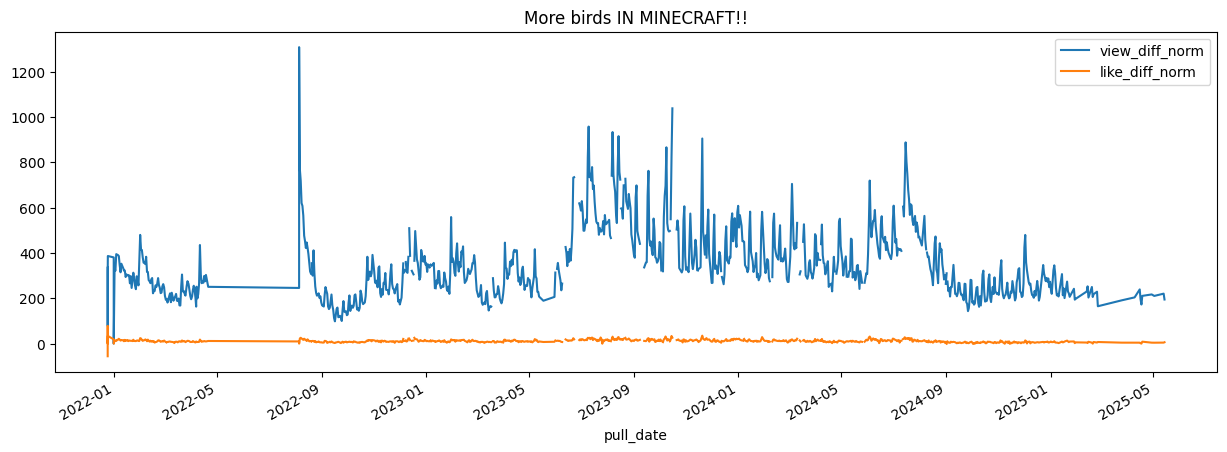

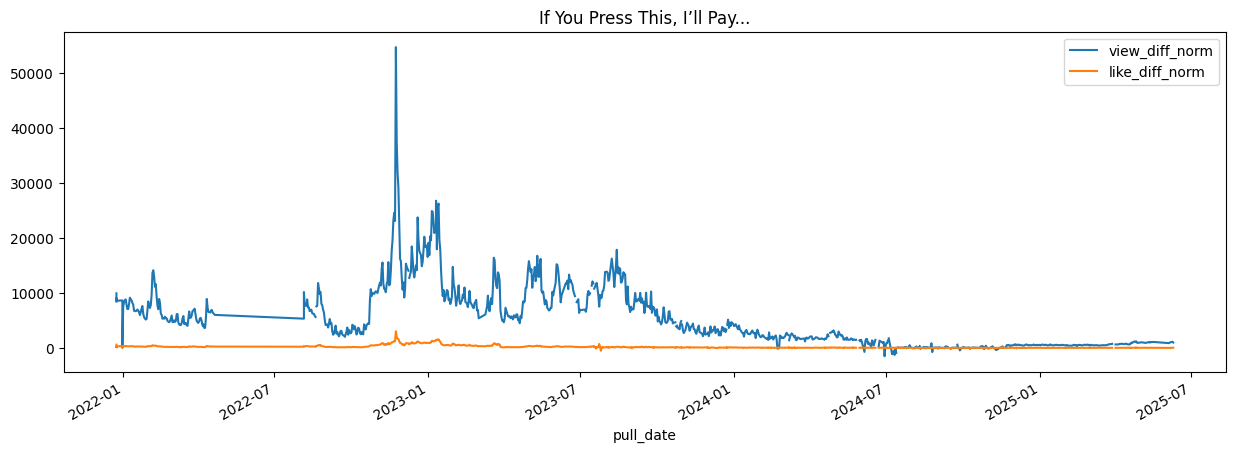

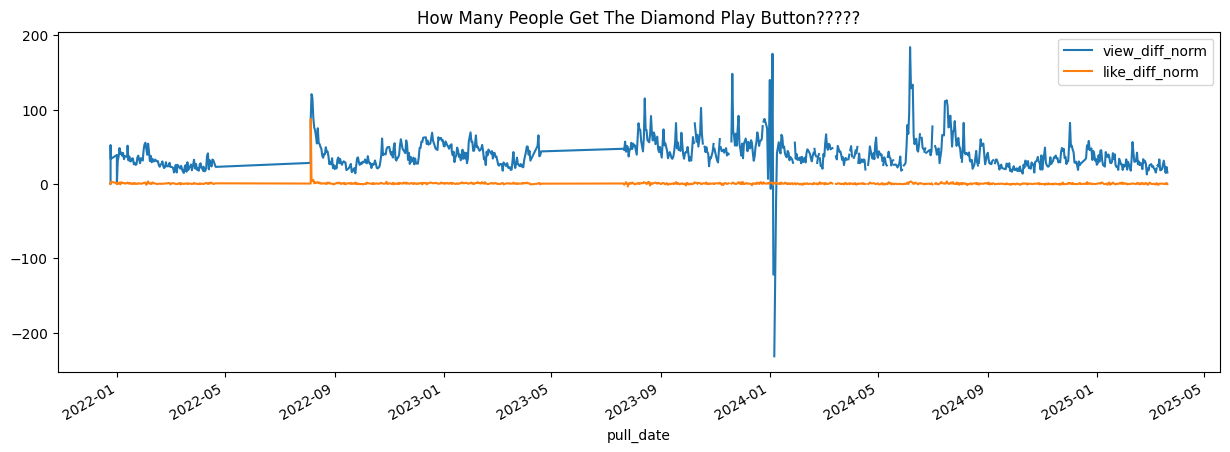

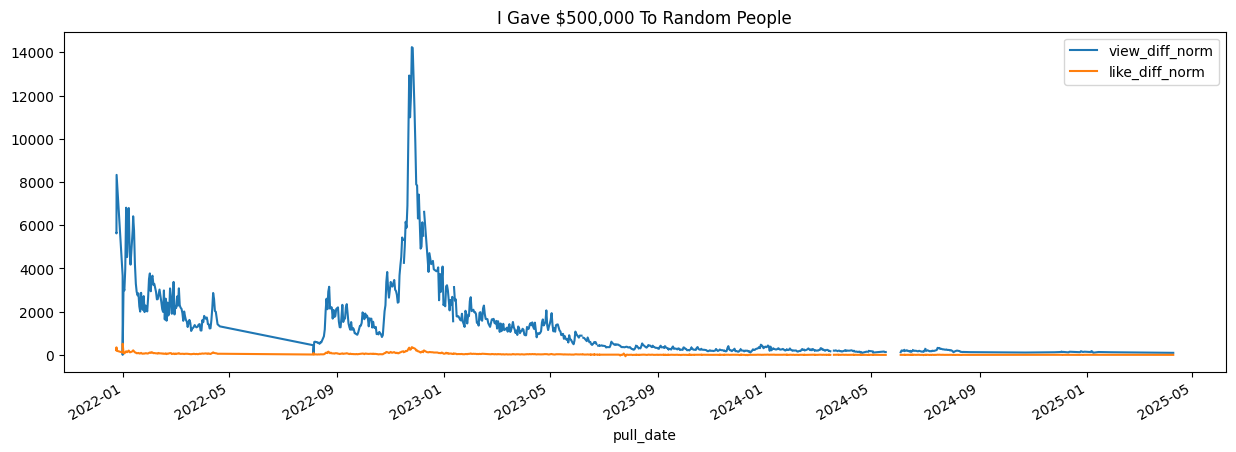

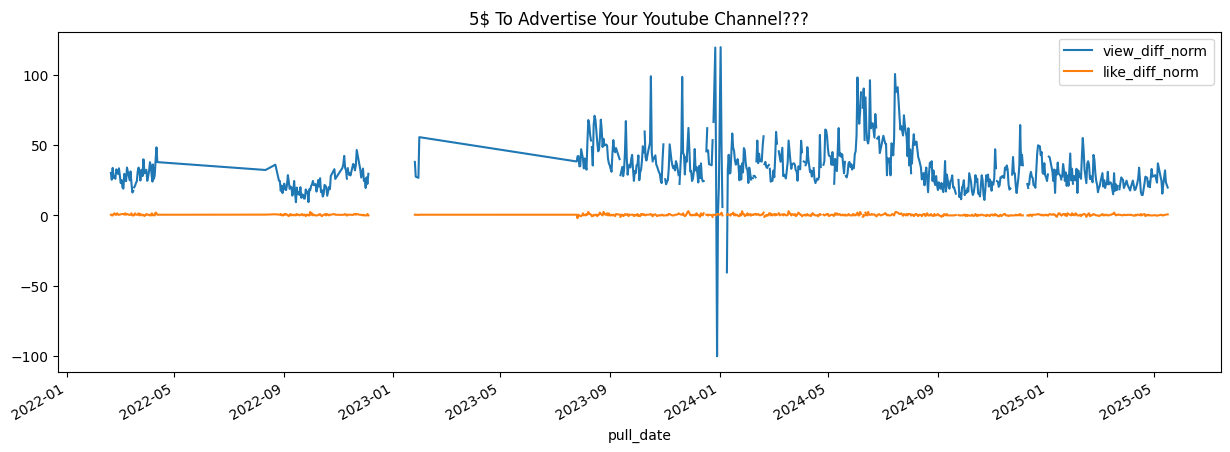

In [17]:
top_10_ids = con.sql("""
    SELECT id FROM (
        SELECT id, MAX(like_ratio_norm) AS max_ratio
        FROM youtube_final
        WHERE like_ratio_norm <= 1
          AND view_diff_norm  != 0
        GROUP BY id
        ORDER BY max_ratio DESC
        LIMIT 10
    )
""").df()['id'].tolist()

for v in top_10_ids:
    vid_title = con.sql(
        f"SELECT title FROM youtube_final WHERE id = '{v}' LIMIT 1"
    ).df()['title'][0]
    (con.sql(f"""
        SELECT pull_date, view_diff_norm, like_diff_norm
        FROM youtube_final
        WHERE id = '{v}'
        ORDER BY pull_date
    """)
    .df()
    .set_index('pull_date')[['view_diff_norm', 'like_diff_norm']]
    .plot(figsize=(15, 5), title=vid_title))

In [18]:
con.sql("""
    SELECT view_count, like_count
    FROM youtube_clean
    WHERE id = 'se50viFJ0AQ'
""").df().corr()

,view_count,like_count
view_count,1.000000,0.992915
like_count,0.992915,1.000000


In [19]:
con.sql("SELECT * FROM youtube_final").df()

,id,title,pull_date,view_count,like_count,comment_count,duration_seconds,time_since_last_pull,view_diff,like_diff,comment_diff,like_to_view_ratio,view_diff_norm,like_diff_norm,like_ratio_norm
0,-0zoWMSEOGg,"I Gave My 6,000,000th Subscriber 6,000,000 ____",2021-12-24 07:11:03.667334+05:30,15052568,353973,33234,1113,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,-0zoWMSEOGg,"I Gave My 6,000,000th Subscriber 6,000,000 ____",2021-12-24 07:23:57.197204+05:30,15052587,353973,33234,1113,773529870,19.0,0.0,0.0,0.000000,1.061110e+03,0.000000,0.000000
2,-0zoWMSEOGg,"I Gave My 6,000,000th Subscriber 6,000,000 ____",2021-12-24 07:33:09.197822+05:30,15052593,353973,33234,1113,552000618,6.0,0.0,0.0,0.000000,4.695647e+02,0.000000,0.000000
3,-0zoWMSEOGg,"I Gave My 6,000,000th Subscriber 6,000,000 ____",2021-12-24 07:46:53.157735+05:30,15052597,353973,33234,1113,823959913,4.0,0.0,0.0,0.000000,2.097189e+02,0.000000,0.000000
4,-0zoWMSEOGg,"I Gave My 6,000,000th Subscriber 6,000,000 ____",2021-12-24 11:41:36.043167+05:30,15052769,353975,33234,1113,14082885432,172.0,2.0,0.0,0.011628,5.276191e+02,6.135106,0.011628
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
450884,zxuICI0kL3s,"Don’t Turn Around, Win $10k",2025-08-06 05:33:02.430098+05:30,158436656,3666206,5532,31,86454740390,11132526.0,225526.0,273.0,0.020258,5.562739e+06,112691.602057,0.020258
450885,zxuICI0kL3s,"Don’t Turn Around, Win $10k",2025-08-07 05:34:31.258029+05:30,165692474,3798626,5612,31,86488827931,7255818.0,132420.0,80.0,0.018250,3.624183e+06,66141.999341,0.018250
450886,zxuICI0kL3s,"Don’t Turn Around, Win $10k",2025-08-08 05:36:04.659983+05:30,171056625,3893536,5719,31,86493401954,5364151.0,94910.0,107.0,0.017693,2.679179e+06,47403.754591,0.017693
450887,zxuICI0kL3s,"Don’t Turn Around, Win $10k",2025-08-09 05:34:03.468001+05:30,173990638,3949685,5803,31,86278808018,2934013.0,56149.0,84.0,0.019137,1.469067e+06,28113.934994,0.019137


<Axes: ylabel='Frequency'>

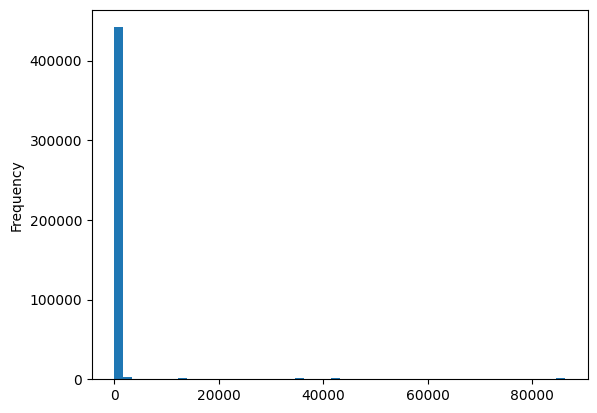

In [20]:
con.sql("""
    SELECT duration_seconds FROM youtube_final
""").df()['duration_seconds'].plot(kind='hist', bins=50)

<Axes: ylabel='Frequency'>

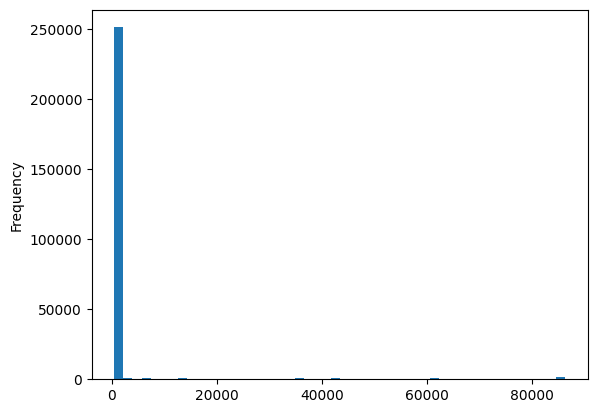

In [21]:
con.sql("""
    SELECT duration_seconds FROM youtube_final
    WHERE duration_seconds > 500
""").df()['duration_seconds'].plot(kind='hist', bins=50)

In [22]:
# QUALIFY is a DuckDB extension that filters on window functions without a subquery
con.sql("""
    CREATE OR REPLACE VIEW latest_videos AS
    SELECT *
    FROM youtube_final
    QUALIFY ROW_NUMBER() OVER (PARTITION BY id ORDER BY pull_date DESC) = 1
""")

In [23]:
con.sql("""
    SELECT *,
        comment_count::DOUBLE / NULLIF(view_count::DOUBLE, 0.0) AS comment_ratio
    FROM latest_videos
    WHERE view_count > 1_000_000
    ORDER BY comment_ratio DESC
""").show()

┌─────────────┬──────────────────────────────────────────────────┬──────────────────────────────────┬────────────┬────────────┬───────────────┬──────────────────┬──────────────────────┬────────────┬───────────┬──────────────┬───────────────────────┬────────────────────┬─────────────────────┬───────────────────────┬────────────────────────┐
│     id      │                      title                       │            pull_date             │ view_count │ like_count │ comment_count │ duration_seconds │ time_since_last_pull │ view_diff  │ like_diff │ comment_diff │  like_to_view_ratio   │   view_diff_norm   │   like_diff_norm    │    like_ratio_norm    │     comment_ratio      │
│   varchar   │                     varchar                      │     timestamp with time zone     │   int64    │   int64    │     int64     │      int64       │        int64         │   double   │  double   │    double    │        double         │       double       │       double        │        double         │